In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use("ggplot")
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

In [2]:
conditioning_list = [4**i for i in range(9)]

# ---- Banana: ode_1..ode_10, mcmc _1.._10 ----
wds_nn_b      = np.zeros((10, 9))
wds_mcmc_b    = np.zeros((10, 9))
wds_nn_std_b  = np.zeros((10, 9))
wds_mcmc_std_b= np.zeros((10, 9))
for i in range(1, 11):
    wds_nn_b[i-1]       = np.load(f"budget_results/ode_{i}/wd_nn_array_mean.npy")
    wds_mcmc_b[i-1]     = np.load(f"budget_results/wd_mcmc_array_mean_{i}.npy")
    wds_nn_std_b[i-1]   = np.load(f"budget_results/ode_{i}/wd_nn_array_std.npy")
    wds_mcmc_std_b[i-1] = np.load(f"budget_results/wd_mcmc_array_std_{i}.npy")
ode_mean_b  = float(np.mean(wds_nn_b))
mcmc_mean_b = np.mean(wds_mcmc_b,     axis=0)
ode_std_b   = np.mean(wds_nn_std_b,   axis=0)
mcmc_std_b  = np.mean(wds_mcmc_std_b, axis=0)

# ---- 8 Gaussians: ode_0..ode_9, mcmc _0.._9 ----
gd = "../8gaussians"
wds_nn_g      = np.zeros((10, 9))
wds_mcmc_g    = np.zeros((10, 9))
wds_nn_std_g  = np.zeros((10, 9))
wds_mcmc_std_g= np.zeros((10, 9))
for i in range(10):
    wds_nn_g[i]       = np.load(os.path.join(gd, f"budget_results/ode_{i}/wd_nn_array_mean.npy"))
    wds_mcmc_g[i]     = np.load(os.path.join(gd, f"budget_results/wd_mcmc_array_mean_{i}.npy"))
    wds_nn_std_g[i]   = np.load(os.path.join(gd, f"budget_results/ode_{i}/wd_nn_array_std.npy"))
    wds_mcmc_std_g[i] = np.load(os.path.join(gd, f"budget_results/wd_mcmc_array_std_{i}.npy"))
ode_mean_g  = float(np.mean(wds_nn_g))
mcmc_mean_g = np.mean(wds_mcmc_g,     axis=0)
ode_std_g   = np.mean(wds_nn_std_g,   axis=0)
mcmc_std_g  = np.mean(wds_mcmc_std_g, axis=0)

# ---- Tanh: ode_1..ode_9, mcmc _1.._9 ----
td = "../tanh"
wds_nn_t      = np.zeros((9, 9))
wds_mcmc_t    = np.zeros((9, 9))
wds_nn_std_t  = np.zeros((9, 9))
wds_mcmc_std_t= np.zeros((9, 9))
for i in range(1, 10):
    wds_nn_t[i-1]       = np.load(os.path.join(td, f"budget_results/ode_{i}/wd_nn_array_mean.npy"))
    wds_mcmc_t[i-1]     = np.load(os.path.join(td, f"budget_results/wd_mcmc_array_mean_{i}.npy"))
    wds_nn_std_t[i-1]   = np.load(os.path.join(td, f"budget_results/ode_{i}/wd_nn_array_std.npy"))
    wds_mcmc_std_t[i-1] = np.load(os.path.join(td, f"budget_results/wd_mcmc_array_std_{i}.npy"))
ode_mean_t  = float(np.mean(wds_nn_t))
mcmc_mean_t = np.mean(wds_mcmc_t,     axis=0)
ode_std_t   = np.mean(wds_nn_std_t,   axis=0)
mcmc_std_t  = np.mean(wds_mcmc_std_t, axis=0)

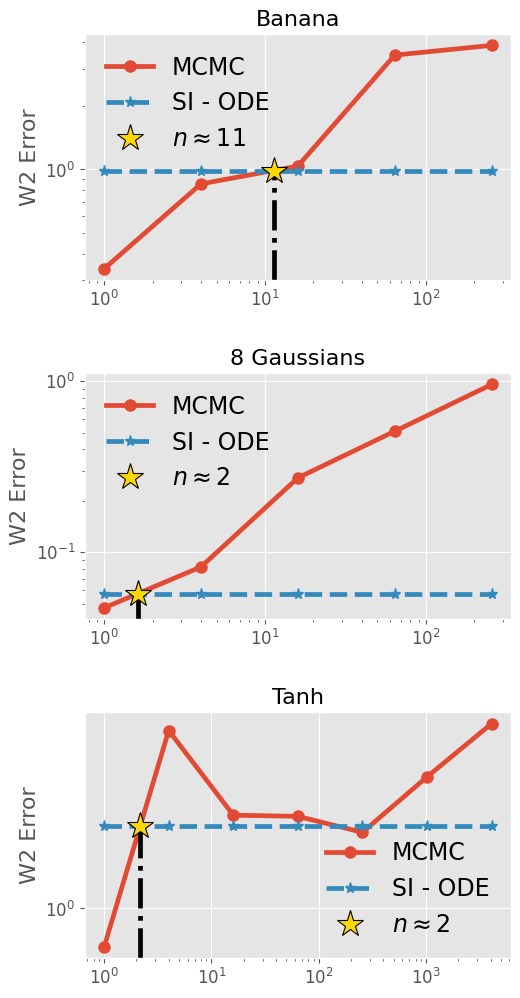

In [9]:
def find_crossing(clist, mcmc_means, ode_mean):
    """Find crossing in log-log space for accuracy on a log-log plot."""
    for lo_i in range(len(clist) - 1):
        lo, hi = mcmc_means[lo_i], mcmc_means[lo_i + 1]
        if min(lo, hi) <= ode_mean <= max(lo, hi):
            x0, x1 = np.log10(clist[lo_i]), np.log10(clist[lo_i + 1])
            y0, y1 = np.log10(lo), np.log10(hi)
            y_target = np.log10(ode_mean)
            x_cross = x0 + (y_target - y0) * (x1 - x0) / (y1 - y0)
            return float(10 ** x_cross)
    return None

def plot_budget(ax, clist, mcmc_mean, ode_mean,
                add_legend=False, legend_loc="lower right", title=""):
    n   = len(clist)
    eps = 1e-10

    ax.plot(clist, mcmc_mean[:n], label="MCMC",
            marker="o", markersize=8, linewidth=3.4)
    ax.plot(clist, ode_mean * np.ones(n), label="SI - ODE",
            marker="*", linestyle="dashed", linewidth=3.4, markersize=8)

    ax.set_yscale("log")
    ax.set_xscale("log")

    vline_idx = find_crossing(clist, mcmc_mean[:n], ode_mean)
    if vline_idx is not None:
        ymin_ax, ymax_ax = ax.get_ylim()
        ymin_ax = max(ymin_ax, eps)
        ymax_norm = np.clip(
            (np.log10(ode_mean) - np.log10(ymin_ax)) /
            (np.log10(ymax_ax)  - np.log10(ymin_ax)),
            0, 1,
        )
        ax.axvline(vline_idx, ymax=ymax_norm, linewidth=3.4,
                   c="black", linestyle="dashdot")
        ax.plot(vline_idx, ode_mean, linestyle="None", marker="*",
                c="gold", markeredgecolor="black",
                markeredgewidth=0.8, markersize=20,
                label=rf"$n \approx {vline_idx:.0f}$")

    ax.set_ylabel("W2 Error", fontsize=16)
    if add_legend:
        ax.legend(loc=legend_loc, fontsize=17, frameon=False)
    if title:
        ax.set_title(title, fontsize=16)

fig, axes = plt.subplots(3, 1, figsize=(5.5, 12))
plt.subplots_adjust(hspace=0.38)

plot_budget(axes[0], conditioning_list[:5],
            mcmc_mean_b, ode_mean_b,
            add_legend=True, title="Banana", legend_loc="upper left")
plot_budget(axes[1], conditioning_list[:5],
            mcmc_mean_g, ode_mean_g,
            add_legend=True, legend_loc="upper left", title="8 Gaussians")
plot_budget(axes[2], conditioning_list[:7],
            mcmc_mean_t, ode_mean_t,
            add_legend=True, title="Tanh")

# Reduce tanh y-ticks to avoid crowding on log scale
axes[2].yaxis.set_major_locator(plt.LogLocator(base=10, numticks=4))
axes[2].yaxis.set_minor_locator(plt.NullLocator())

os.makedirs("images", exist_ok=True)
plt.savefig("images/budget_comparison.png", dpi=300, bbox_inches="tight")
plt.show()